In [1]:
!pip install numpy=="2.2.5" scipy=="1.15.2"

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, solve, inv
from scipy.optimize import fsolve
from scipy.sparse.linalg import gmres

In [34]:
def initial_point(c, theta):
    n  = c.size
    e  = np.ones(n)
    
    x0 = np.zeros(n)
    y0 = e
    z0 = e
    mu0 = 4 * (1 + norm(c) ** 2)
    
    lam0 = mu0 - c / 2
    gam0 = mu0 + c / 2
    
    return x0, y0, z0, lam0, gam0, mu0

In [35]:
def kappa(x, y, z, lam, gam, mu, H, c, nc):
    n = c.size
    e = np.ones(n)
    Hx = H @ x
    rX = Hx + lam - gam + c
    rY = x + y - e
    rZ = x - z + e
    ret = (norm(rY) + norm(rZ)) / (2 * n) + \
           norm(rX) / max(1, nc) + \
           mu / max(1, norm(x @ Hx + c))
    return ret

In [36]:
from scipy.sparse.linalg import LinearOperator, gmres, minres, bicgstab

def make_A_op(H, lam, y, gam, z):
    n = H.shape[0]
   
    Yi    = 1.0 / y
    B     = z * Yi
    diag0 = B * lam + gam         
    Hd    = H.diagonal()        
    diagA = diag0 + z * Hd
    P     = 1.0 / diagA      

    def matvec(v):
        Hz = H.dot(v)          
        out = z * Hz
        out += diag0 * v
        return P * out

    return LinearOperator((n,n), matvec, dtype=float), P

In [37]:
def newton_step(H, lam, y, gam, z, tol=1e-5, restart=50, symm=False):
    n = H.shape[0]

    # build operator and P
    A_op, P = make_A_op(H, lam, y, gam, z)

    Yi = 1.0 / y
    a  = lam * y
    b  = gam * z

    B  = z * Yi
    rhs1 = P * (b - B*a)

    x_d = bicgstab(A_op, rhs1, rtol=tol)[0]
    y_d = -x_d
    z_d =  x_d
    lam_d = Yi * (lam * x_d + a)
    gam_d = lam_d + H.dot(x_d)

    a_dot = -2 * lam_d * y_d
    b_dot = -2 * gam_d * z_d
    rhs2  = P * (b_dot - B*a_dot)

    x_dd = bicgstab(A_op, rhs2, rtol=tol)[0]
    y_dd = -x_dd
    z_dd =  x_dd
    lam_dd = Yi * (lam * x_dd - 2 * lam_d * y_d)
    gam_dd = lam_dd + H.dot(x_dd)

    return x_d, y_d, z_d, lam_d, gam_d, x_dd, y_dd, z_dd, lam_dd, gam_dd

In [38]:
def step_along_arc( x   , y   , z   , lam   , gam  \
                  , x_d , y_d , z_d , lam_d , gam_d \
                  , x_dd, y_dd, z_dd, lam_dd, gam_dd \
                  , sin_a, mu \
                  , p_dd_w_dd, w_d_p_d \
                  , p_d_w_dd, w_d_p_dd): 
    n     = x.size
    cos_a = np.sqrt(1 - sin_a**2)
    p_d  = np.concatenate([  y_d ,   z_d ])
    w_d  = np.concatenate([lam_d , gam_d ])
    p_dd = np.concatenate([  y_dd,   z_dd])
    w_dd = np.concatenate([lam_dd, gam_dd])
    
    mu_a = mu * (1 - sin_a)                                     \
         + (                                                    \
               (p_dd_w_dd - w_d_p_d) *         (1 - cos_a)**2 - \
               (p_d_w_dd + w_d_p_dd) * sin_a * (1 - cos_a)      \
           ) / (2 * n)
    
    return (
        x - x_d * sin_a + x_dd * (1 - cos_a),
        y - y_d * sin_a + y_dd * (1 - cos_a),
        z - z_d * sin_a + z_dd * (1 - cos_a),
        lam - lam_d * sin_a + lam_dd * (1 - cos_a),
        gam - gam_d * sin_a + gam_dd * (1 - cos_a),
        mu_a
    )

In [39]:
def correct_step(H, lam, y, gam, z, mu, tol=1e-6, restart=50, symm=False):
    n = H.shape[0]

    A_op, P = make_A_op(H, lam, y, gam, z)

    Yi = 1.0 / y
    e  = np.ones(n)
    B  = z * Yi
    a  = mu*e - lam*y
    b  = mu*e - gam*z
    rhs = P * (b - B*a)

    dx = bicgstab(A_op, rhs, rtol=tol)[0]
    dy = -dx
    dz =  dx
    dlam = Yi * (lam * dx + a)
    dgam = dlam + H.dot(dx)

    return dx, dy, dz, dlam, dgam

In [40]:
def update(x, y, z, lam, gam, mu, H):
    n   = x.size
    upd = lambda v, dv: v + dv
    
    dx, dy, dz, dlam, dgam = correct_step(H, lam, y, gam, z, mu)
    
    x1   = x + dx
    y1   = y + dy
    z1   = z + dz
    lam1 = lam + dlam
    gam1 = gam + dgam
    mu1  = (y1 @ lam1 + z1 @ gam1) / (2 * n)
    
    return x1, y1, z1, lam1, gam1, mu1

In [41]:
def step_size(mu, theta, x_d, p_d, w_d, p_dd, w_dd, sigma):
    n = p_d.size
    e = np.ones(n)

    p_d_w_dd  = p_d  @ w_dd
    p_dd_w_dd = p_dd @ w_dd
    w_d_p_dd  = w_d  @ p_dd
    w_d_p_d   = w_d  @ p_d
    
    sin_a_flat = fsolve(
        lambda x: mu * (1 - x) - w_d_p_d * (x**4 + x**2) / (2 * n) - sigma,
        0.99
    )
    
    b0 = -theta * mu
    b1 = -b0
    b3 = norm(p_d  * w_dd + w_d * p_dd - (p_d_w_dd + w_d_p_dd) * e / (2 * n)) + theta / n * (p_d_w_dd + w_d_p_dd)
    b4 = norm(p_dd * w_dd - w_d * p_d  - (p_dd_w_dd - w_d_p_d) * e / (2 * n)) - theta / n * (p_dd_w_dd - w_d_p_d)
    
    b0_hat = b0
    b1_hat = b1
    b3_hat = max(b3, 0.0)
    b4_hat = max(b4, 0.0)
    
    sin_a_wave = fsolve(
        lambda x: (
            b4_hat *     (1 - np.sqrt(1 - x**2))**2 +
            b3_hat * x * (1 - np.sqrt(1 - x**2))    +
            b1_hat * x                              +
            b0_hat
        ),
        0.99
    )
    
    a0 = b0
    a1 = b1
    a2 = theta * (x_d @ (H @ x_d)) / n
    a3 = norm(p_d  * w_dd + w_d * p_dd - (p_d_w_dd + w_d_p_dd) * e / (2 * n))
    a4 = norm(p_dd * w_dd - w_d * p_d  - (p_dd_w_dd - w_d_p_d) * e / (2 * n)) + a2
    
    sin_a_strike = fsolve(
        lambda x: a4 * x**4 + a3 * x**3 + a2 * x**2 + a1 * x + a0,
        0.99
    )
    
    sin_a_galka = max(sin_a_wave, sin_a_strike)
    
    beta  = p_dd_w_dd / (2 * n * mu)
    bi2   =  1 / (2 * beta)
    one63 = (1 / 6)**3
    
    a_C1_galka = (
        np.pi / 2 if beta <= 1 / 6 else
        np.arcsin(
            np.cbrt(bi2 + np.sqrt(bi2**2 + one63)) +
            np.cbrt(bi2 - np.sqrt(bi2**2 + one63))
        )
    )
    
    return min(sin_a_flat, sin_a_galka, np.sin(a_C1_galka)), p_dd_w_dd, w_d_p_d, p_d_w_dd, w_d_p_dd

In [42]:
def solve_qp_arcsearch(H, c, theta=0.19, eps=1e-8, sigma=1e-10, max_iter=50):
    x, y, z, lam, gam, mu = initial_point(c, theta)
    nc = norm(c)
    k = kappa(x, y, z, lam, gam, mu, H, c, nc)
  
    dual_meas_hist = []
    step_hist      = []
    loss_hist      = []
    gap_hist       = []
    
    for it in range(max_iter):
        if k <= eps:
            break

        # 1) Newton step
        x_d, y_d, z_d, lam_d, gam_d, x_dd, y_dd, z_dd, lam_dd, gam_dd = newton_step(H, lam, y, gam, z)

        # 2) Choose new step
        p_d  = np.concatenate([   y_d,    z_d])
        w_d  = np.concatenate([ lam_d,  gam_d])
        p_dd = np.concatenate([  y_dd,   z_dd])
        w_dd = np.concatenate([lam_dd, gam_dd])
        
        sin_a, p_dd_w_dd, w_d_p_d, p_d_w_dd, w_d_p_dd = step_size(mu, theta, x_d, p_d, w_d, p_dd, w_dd, sigma)

        # 3) Do step along arc
        x_a, y_a, z_a, lam_a, gam_a, mu_a = step_along_arc \
        (
            x   , y   , z   , lam   , gam   , \
            x_d , y_d , z_d , lam_d , gam_d , \
            x_dd, y_dd, z_dd, lam_dd, gam_dd, \
            sin_a, mu, p_dd_w_dd, w_d_p_d, p_d_w_dd, w_d_p_dd \
        )

        # 4) Back to proximal vicinity: N(2O) -> N(O)
        x, y, z, lam, gam, mu = update(x_a, y_a, z_a, lam_a, gam_a, mu_a, H)

        #print(y)
        assert (y   >= 0).all()
        assert (z   >= 0).all()
        assert (lam >= 0).all()
        assert (mu  >= 0).all()

        # 5) Update kappa for termination criteria
        k = kappa(x, y, z, lam, gam, mu, H, c, nc)

        dual_meas_hist.append(mu)
        step_hist     .append(sin_a)
        loss_hist     .append(0.5 * x @ (H @ x) + c @ x) # for debug
        gap_hist      .append(k)
        
        #print("mu: ", mu)
        #print("Kappa: ", k)
        #print("Step: ", sin_a)
    return x, dual_meas_hist, step_hist, loss_hist, gap_hist

In [43]:
import numpy as np

def compute_lqr_matrices(A, B, P, Q, R, x0, N):
    r, m = B.shape
    
    powers = [B]
    for i in range(1, N):
        powers.append(A @ powers[-1])  # [B, A B, A^2 B, ..., A^{N-1} B]
    
    x_k = [x0]
    for k in range(1, N + 1):
        x_k.append(A @ x_k[-1])  # [x0, A x0, A^2 x0, ..., A^N x0]
    
    # Compute phi_N = [A^{N-1} B, A^{N-2} B, ..., B]
    phiN = np.hstack(powers[::-1])
    H    = phiN.  T @ P @ phiN  # Terminal cost contribution
    c    = x_k[N].T @ P @ phiN  # Terminal cost linear term
    
    # Stage costs
    for k in range(1, N):
        # phi_k = [A^{k-1} B, A^{k-2} B, ..., B]
        phi_k = np.hstack(powers[:k][::-1])
        H[:k*m, :k*m] += phi_k. T @ Q @ phi_k  # Stage cost quadratic term
        c[:k*m      ] += x_k[k].T @ Q @ phi_k  # Stage cost linear term
    
    H += np.eye(N*m) * R  # Control cost contribution
    c = c.flatten()
    return H, c

In [44]:
T = 50.0
N = 1000
h = T / N

# System matrices
A = np.array([[1, h], [-h, 1]])
B = np.array([[0], [h]])

#for sliding mode
C = np.array([1, 2])

# Cost weights
P = np.array([[2, 0], [0, 1]])
Q = P.copy()
R = 6.0

# Initial state
x0 = np.array([15.0, 5.0])

# Compute H and c
H, c = compute_lqr_matrices(A, B, P, Q, R, x0, N)

In [45]:
import time
start = time.time()
u_MPC, dual_meas, step, loss, gap = solve_qp_arcsearch(H, c, theta=0.19, eps=1e-8, sigma=1e-10, max_iter=100)
end = time.time()
print(end - start)

0.21595001220703125


In [46]:
#import cProfile
#cProfile.run("solve_qp_arcsearch(H, c)")

In [51]:
def simulate_control_system(control_type):
    t = np.linspace(0, T, N + 1)
    x_traj = np.zeros((2, N + 1))
    x_traj[:, 0] = x0

    x_target = [0, 0]
    
    u_opt = []
    
    if control_type == 'PID':

        class PIDController:
            def __init__(self, K_p, K_d, h, output_limits=(-float('inf'), float('inf'))):
                self.K_p = K_p
                self.K_d = K_d
                self.h = h
                self.last_error = 0.0
                self.min_output, self.max_output = output_limits
                self.loss = 0.0
                

            def update(self, x_current, x_target):
                error = x_current - x_target
            
                P = self.K_p @ error
                D = self.K_d @ (error - self.last_error) / self.h
                self.last_error = error
                u = P + D

                u_clamped = np.clip(u, self.min_output, self.max_output)
                return u_clamped
      
        pid = PIDController(K_p=np.array([2.0, 2.0]), K_d=np.array([0.5, 0.5]), h=h, output_limits=(-1, 1))
        
        for k in range(N):
            u = pid.update(x_traj[:, k], x_target)
            Bu = B.flatten() * u
            u_opt.append(u)
            x_traj[:, k + 1] = A @ x_traj[:, k] - B.flatten() * u
            
    elif control_type == 'sliding_mode':
        class SlidingMode:
            def __init__(self, A, B, C, K=0.5, phi=0.1, output_limits=(-1, 1)):
                self.A = A
                self.B = B
                self.C = C
                self.K = K
                self.phi = phi
                self.min_output, self.max_output = output_limits

            def update(self, x):
                s = self.C @ x
                CB = self.C @ self.B
                
                if np.abs(CB) < 1e-6:
                    u_eq = 0.0
                else:
                    u_eq = - (1 / CB) * (self.C @ self.A @ x)
                
                u_sw = - self.K * np.tanh(s / self.phi)  
                u = u_eq + u_sw
                return np.clip(u, self.min_output, self.max_output)
        
         # s = x1 + 0.5*x2
        sliding = SlidingMode(A, B, C, K=0.4, phi=0.09)
        
        for k in range(N):
            u = sliding.update(x_traj[:, k])
            Bu = B.flatten() * u
            u_opt.append(u[0])
            x_traj[:, k + 1] = A @ x_traj[:, k] + B.flatten() * u

    elif control_type == 'MPC':
        x_traj = x_traj_MPC
        u_opt = u_MPC
    
    return t, x_traj, u_opt

In [52]:
# time axis
t = np.linspace(0, T, N + 1)
x_traj_MPC = np.zeros((2, N + 1))
x_traj_MPC[:, 0] = x0
cost = [np.float64(0)]
for k in range(N):
    u = u_MPC[k]
    cost.append(R * u * u + x_traj_MPC[:, k] @ Q @ x_traj_MPC[:, k] + cost[-1])
    x_traj_MPC[:, k + 1] = A @ x_traj_MPC[:, k] + B.flatten() * u

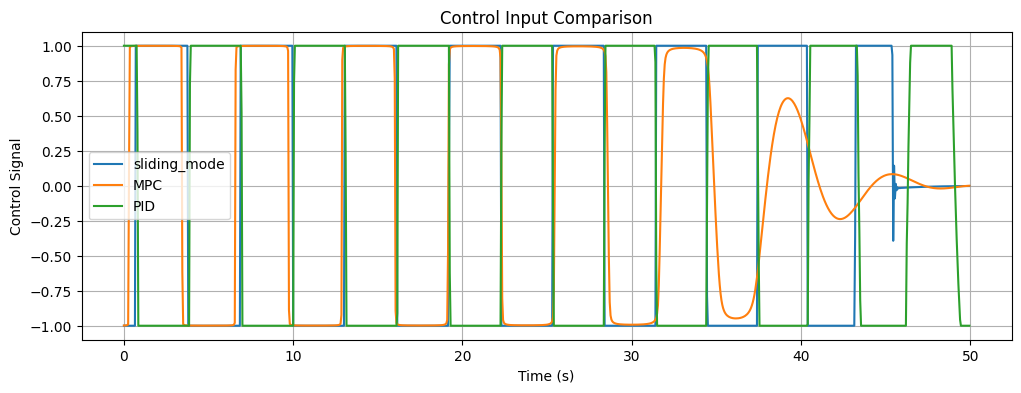

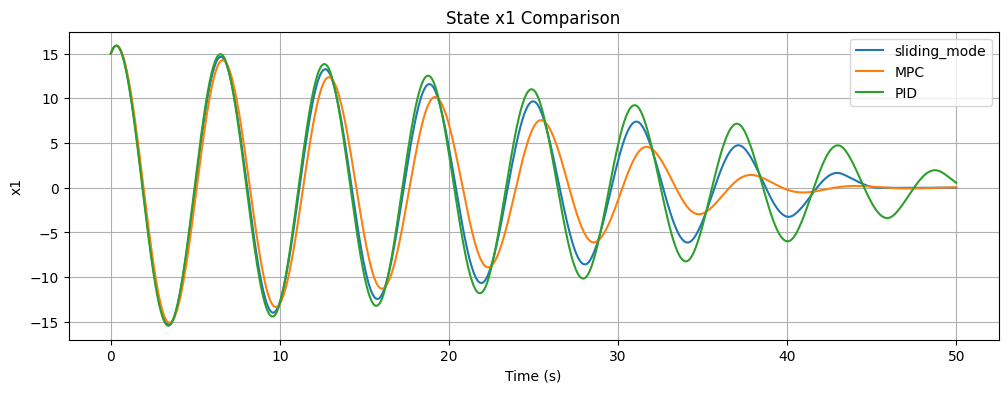

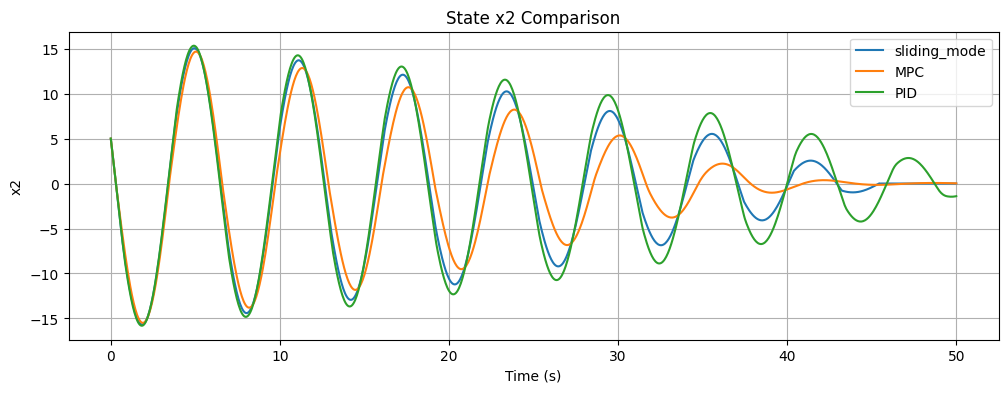

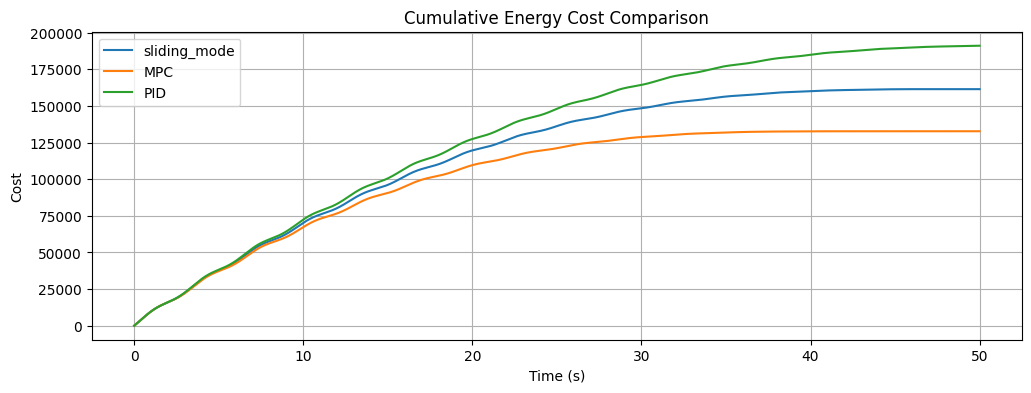

In [53]:
controller_types = ['sliding_mode', 'MPC', 'PID']
results = {}


for ctrl in controller_types:
    t, x_traj, u_opt = simulate_control_system(control_type=ctrl)
    cost = [np.float64(0)]
    for i in range(len(u_opt)):
        u = u_opt[i]
        cost.append((x_traj[:, i] @ Q) @ x_traj[:, i] + u * R * u + cost[-1])
    results[ctrl] = {
        't': t,
        'x_traj': x_traj,
        'u_opt': u_opt,
        'cost': cost
    }

# Plot Control Input
plt.figure(figsize=(12, 4))
for ctrl in controller_types:
    plt.plot(results[ctrl]['t'][:-1], results[ctrl]['u_opt'], label=ctrl)
plt.title('Control Input Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Control Signal')
plt.grid(True)
plt.legend()

# Plot State x1
plt.figure(figsize=(12, 4))
for ctrl in controller_types:
    plt.plot(results[ctrl]['t'], results[ctrl]['x_traj'][0, :], label=ctrl)
plt.title('State x1 Comparison')
plt.xlabel('Time (s)')
plt.ylabel('x1')
plt.grid(True)
plt.legend()

# Plot State x2
plt.figure(figsize=(12, 4))
for ctrl in controller_types:
    plt.plot(results[ctrl]['t'], results[ctrl]['x_traj'][1, :], label=ctrl)
plt.title('State x2 Comparison')
plt.xlabel('Time (s)')
plt.ylabel('x2')
plt.grid(True)
plt.legend()

# Plot Energy Cost
plt.figure(figsize=(12, 4))
for ctrl in controller_types:
    plt.plot(results[ctrl]['t'], results[ctrl]['cost'], label=ctrl)
plt.title('Cumulative Energy Cost Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Cost')
plt.grid(True)
plt.legend()
plt.show()

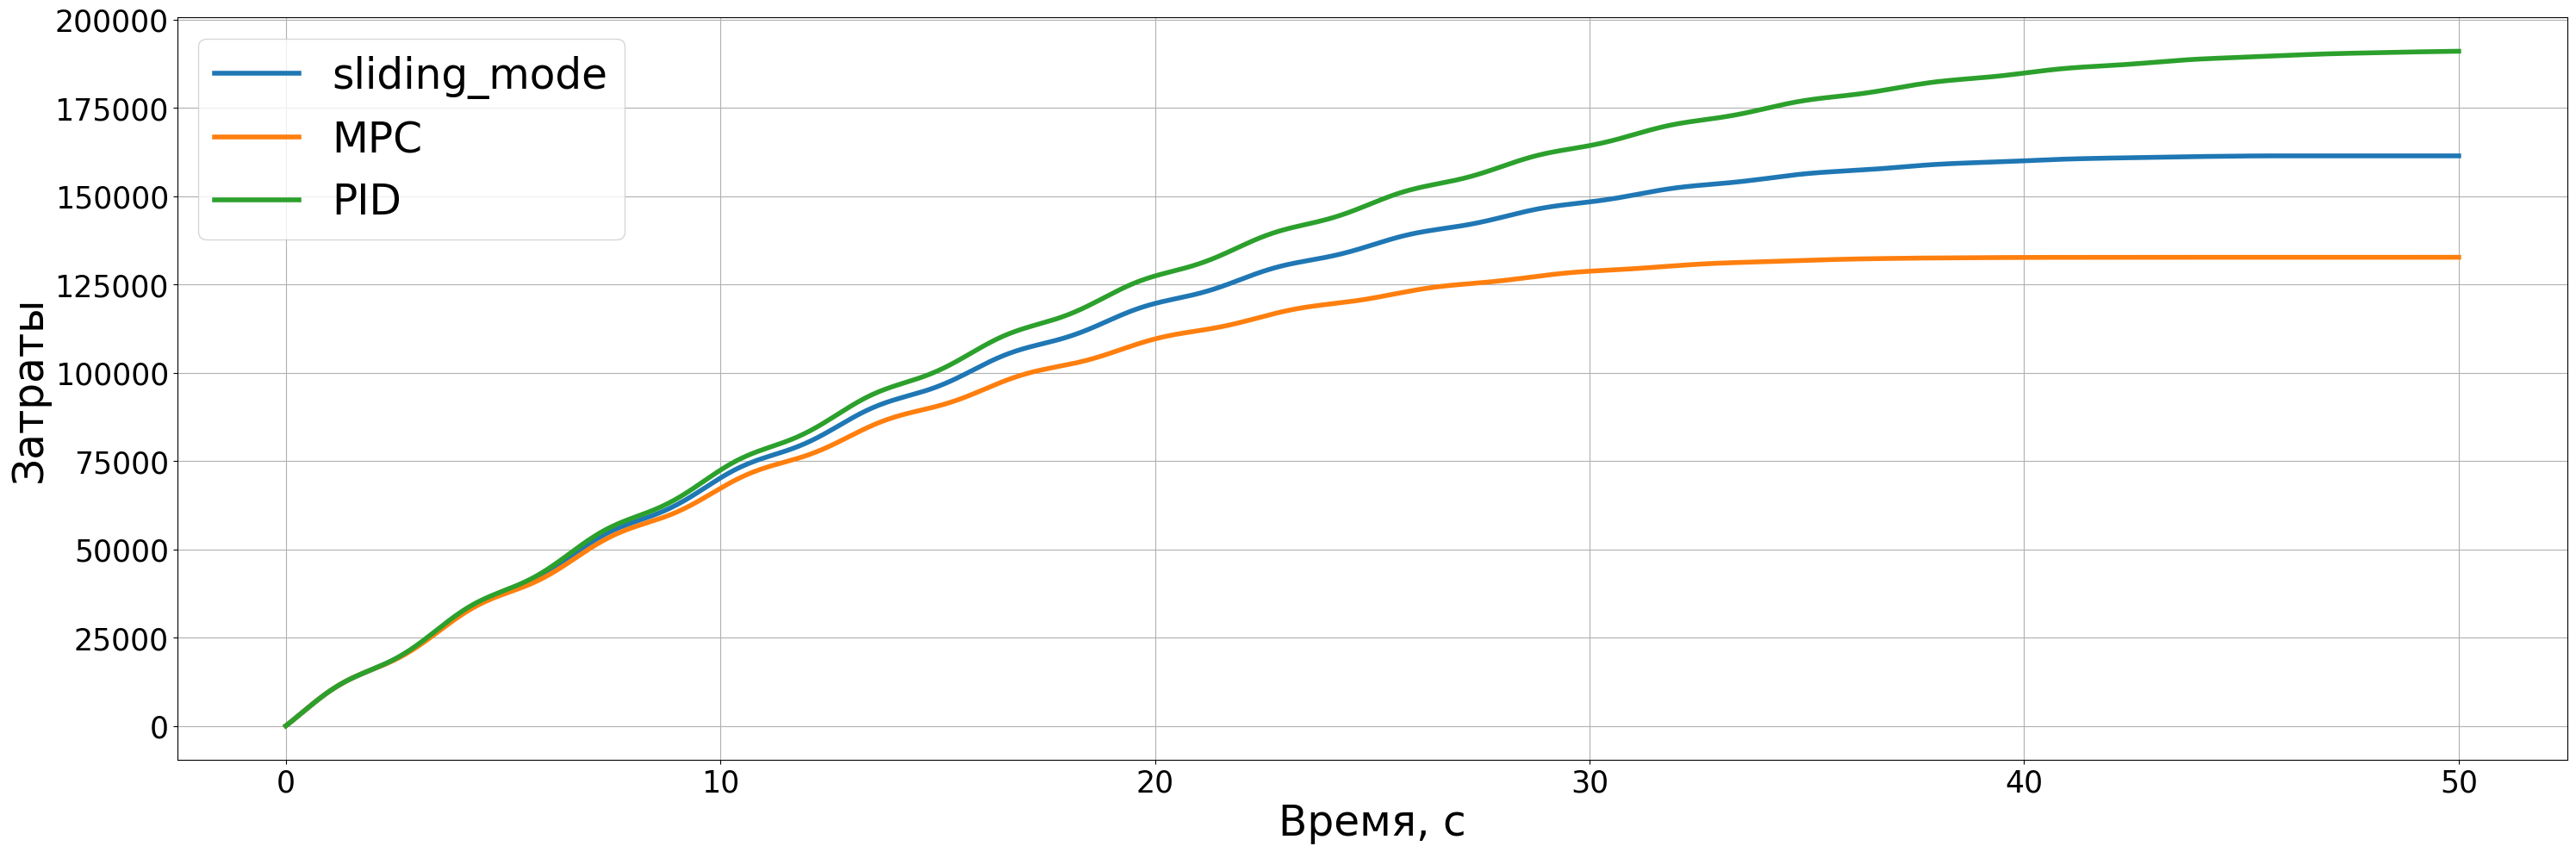

In [56]:
plt.figure(figsize=(30, 10))
plt.tick_params(axis='both', labelsize=25)
for ctrl in controller_types:
    plt.plot(results[ctrl]['t'], results[ctrl]['cost'], label=ctrl, linewidth=4)
plt.xlabel('Время, с', fontsize=35)
plt.ylabel('Затраты', fontsize=35)
plt.grid(True)
plt.legend(fontsize=35)
plt.tight_layout() 
plt.savefig("Cost.png")
plt.show()

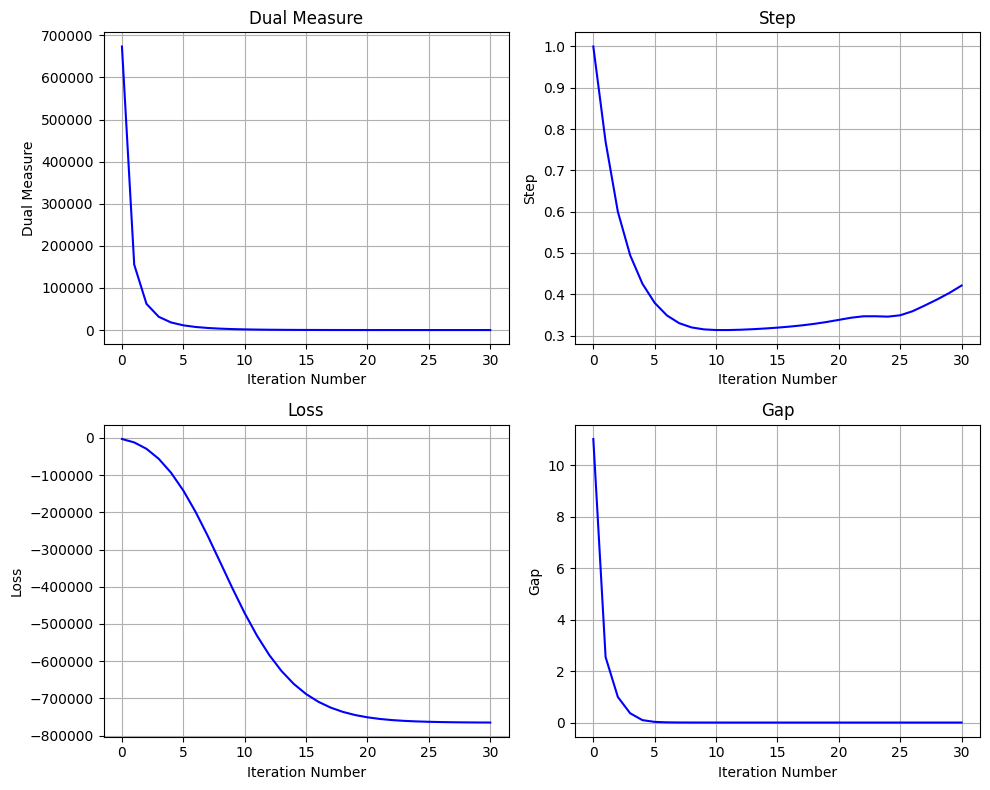

In [19]:
# Create iteration numbers for x-axis
iterations = np.arange(len(loss))

# Create a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # Flatten to easily iterate over subplots

# List of parameters and their names
parameters = [dual_meas, step, loss, gap]
param_names = ['Dual Measure', 'Step', 'Loss', 'Gap']

# Plot each parameter in its subplot
for i, (param, name) in enumerate(zip(parameters, param_names)):
    axes[i].plot(iterations, param, 'b-')
    axes[i].set_title(name)
    axes[i].set_xlabel('Iteration Number')
    axes[i].set_ylabel(name)
    axes[i].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot to a file
plt.show()